# IMT 573 - Problem Set 7 - Regression

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

5. Partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are *strongly* encouraged to attempt each question and document their reasoning process even if they cannot find the correct answer. 

6. After completing the assignment, ensure that your code can run from start to finish without issue. Restart the kernal and run all cells to double check.

Name: Andy Nguyen

Collaborators: 

For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

Previously, we examined police beat data joined with census tracts. In this problem set, we will perform regression analysis on this data.



### Problem 1: Load and examine crime data

#### (a) Load the beat and census data

You'll find a trimmed version of the beats and census data in the `census_beat_data_trimmed.csv` file. Load this data into a DataFrame. Note the variables in the data set.

In [2]:
#Load the census_beat_data_trimmed.csv file
df = pd.read_csv("census_beat_data_trimmed.csv")

#Display a few rows and summary info
print(df.head())

                 geo_id             pri_offense_desc  year  pop_18_24  \
0  1400000US53033009200          NARC-POSSESS-MARIJU  2012        118   
1  1400000US53033003202         ROBBERY-BUSINESS-GUN  2012        181   
2  1400000US53033004600               VEH-THEFT-AUTO  2012        224   
3  1400000US53033008600                   DUI-LIQUOR  2012       2975   
4  1400000US53033007502  ROBBERY-RESIDENCE-BODYFORCE  2012        322   

   pop_25_over  ed_high_sch_grad_higher_25_over  \
0         2557                             2106   
1         3656                             3656   
2         2690                             2646   
3         3436                             3316   
4         2247                             2247   

   ed_bach_deg_grad_higher_25_over  
0                              985  
1                             2506  
2                             2111  
3                             2154  
4                             1781  


The dataset combines police beat-level crime information with demographic and socioeconomic data from the U.S. Census. Key variables include:

geo_id – A unique geographic identifier for each police beat.

pri_offense_desc – The primary offense description (e.g., “NARC–POSSESS–MARIJU,” “ROBBERY–BUSINESS–GUN”).

year – The year in which the offense occurred.

pop_18_24 – Population aged 18 to 24 within the beat.

pop_25_over – Population aged 25 and over.

ed_high_sch_grad_higher_25_over – Number of residents aged 25+ who have at least a high school diploma.

ed_bach_deg_grad_higher_25_over – Number of residents aged 25+ who hold a bachelor’s degree or higher.

#### (b) Examine years in data

Next, examine the years that are present in the dataset. Does it look as though there are years with incomplete or missing data? Filter the data such that it only contains data from the years 2016-2018 (inclusive).

In [3]:
#Examine the distinct years in the dataset
print("Unique years in the data:", sorted(df['year'].unique()))

#Count how many records exist for each year
print("\nRecord counts by year:")
print(df['year'].value_counts().sort_index())

#Check for missing or incomplete data
missing_years = df['year'].isna().sum()
print(f"\nMissing 'year' values: {missing_years}")

#Filter the data for years 2016–2018 (inclusive)
df_filtered = df[(df['year'] >= 2016) & (df['year'] <= 2018)]

Unique years in the data: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]

Record counts by year:
year
2012    40768
2013    45259
2014    49101
2015    47491
2016    48957
2017    49959
2018    50922
2019    15523
Name: count, dtype: int64

Missing 'year' values: 0


### Problem 2: Filter and create variables

#### (a) Examine crime types

For this analysis, we will limit the data to only include crimes of interest. The `pri_offense_desc` variable in the dataset refers to a description of the primary offense in the crimes dataset. This description contains a broad categorization of the crime followed by more specific cateogorizations (separated by hyphens). What are the five most common types of crime in the dataset based only on the broadest cateogorization (i.e. examining categories before the first hyphen)? 

In [4]:

#Make a copy of your filtered dataset if needed
crime_df = df_filtered.copy()

#Extract the broadest crime category
crime_df['broad_category'] = crime_df['pri_offense_desc'].str.split('-').str[0].str.strip()

#Display the five most common crime types
top5_crimes = crime_df['broad_category'].value_counts().head(5)
print("Top 5 most common broad crime categories:")
print(top5_crimes)

Top 5 most common broad crime categories:
broad_category
THEFT       79672
BURGLARY    23271
VEH         11633
TRESPASS     8670
ASSLT        7306
Name: count, dtype: int64


#### (b) Filter by crime type

Filter the data so that it only contains the top-3 most frequent of the (broadest) crime categorizations. What are the dimensions of the dataset?

In [5]:
df_filtered = df_filtered.copy()

#Create the broad_category column
df_filtered['broad_category'] = df_filtered['pri_offense_desc'].str.split('-').str[0].str.strip()

#Find the top 3 most common broad categories
top3 = df_filtered['broad_category'].value_counts().head(3).index
print("Top 3 most common broad crime categories:", list(top3))

#Filter the dataset to only include those top 3 categories
df_top3 = df_filtered[df_filtered['broad_category'].isin(top3)].copy()

#Display the new dataset dimensions
print("\nFiltered dataset shape:", df_top3.shape)
print("Number of rows:", df_top3.shape[0])
print("Number of columns:", df_top3.shape[1])

Top 3 most common broad crime categories: ['THEFT', 'BURGLARY', 'VEH']

Filtered dataset shape: (114576, 8)
Number of rows: 114576
Number of columns: 8


#### (c) Aggregate data

The unit of observation in the crime/census data is individual crimes. We want to analyze the data at the census tract level. That necessitates aggregating the data for each of the census tracts. You may remember we had joined the census data to the crime data for non-specific years (i.e. the data was duplicated across years). To start, create a DataFrame of aggregated data named `data_agg` that has the following columns: 

- `geo_id` (which you will aggregate by), 
- `year` (which you will aggregate by), 
- `pop_18_24` (which can be duplicated for each `geo_id`/`year` combination)
- `pop_25_over` (which can be duplicated for each `geo_id`/`year` combination)
- `ed_high_sch_grad_higher_25_over` (which can be duplicated for each `geo_id`/`year` combination)
- `ed_bach_deg_grad_higher_25_over` (which can be duplicated for each `geo_id`/`year` combination)
- `num_crimes` (which will be a count of the number of crimes per `geo_id`/`year` combination)

In [6]:
cols_first = [
    'pop_18_24',
    'pop_25_over',
    'ed_high_sch_grad_higher_25_over',
    'ed_bach_deg_grad_higher_25_over'
]

data_agg = (
    df_filtered
      .groupby(['geo_id', 'year'], as_index=False)
      .agg({**{c: 'first' for c in cols_first}, 'pri_offense_desc': 'size'})
      .rename(columns={'pri_offense_desc': 'num_crimes'})
)

print("data_agg shape:", data_agg.shape)

data_agg shape: (150, 7)


In [7]:
data_agg.head()

,geo_id,year,pop_18_24,pop_25_over,ed_high_sch_grad_higher_25_over,ed_bach_deg_grad_higher_25_over,num_crimes
0,1400000US53033000202,2016,228,3194,2938,1910,793
1,1400000US53033000202,2017,228,3194,2938,1910,852
2,1400000US53033000202,2018,228,3194,2938,1910,787
3,1400000US53033000602,2016,312,2837,2575,1349,770
4,1400000US53033000602,2017,312,2837,2575,1349,702


#### (d) Calculate proportions

The `ed_high_sch_grad_higher_25_over` and `ed_bach_deg_grad_higher_25_over` variables refer to counts from the population. Create normalized versions of these variables named `high_sch_grad_prop` and `coll_grad_prop` that are normalized by the population that is 25 years and older in each tract.

In [8]:
#Create proportion (normalized) columns
data_agg['high_sch_grad_prop'] = (
    data_agg['ed_high_sch_grad_higher_25_over'] / data_agg['pop_25_over']
)

data_agg['coll_grad_prop'] = (
    data_agg['ed_bach_deg_grad_higher_25_over'] / data_agg['pop_25_over']
)

#Quick check
print(data_agg[['geo_id', 'year', 'high_sch_grad_prop', 'coll_grad_prop']].head())

                 geo_id  year  high_sch_grad_prop  coll_grad_prop
0  1400000US53033000202  2016            0.919850        0.597996
1  1400000US53033000202  2017            0.919850        0.597996
2  1400000US53033000202  2018            0.919850        0.597996
3  1400000US53033000602  2016            0.907649        0.475502
4  1400000US53033000602  2017            0.907649        0.475502


### Problem 3: Integrate household data

#### (a) Load and examine data

The `household_data.csv` file contains data on the number of households and the number of households with children for the census tracts of interest. Load the data and examine the distributions of the variables (not including `geo_id`).

In [9]:
#Load the household data
household_df = pd.read_csv("household_data.csv")

#Display a few rows and summary info
print(household_df.head())
print("\nShape of data:", household_df.shape)
print("\nMissing values:\n", household_df.isna().sum())
print("\nSummary statistics (excluding geo_id):\n", household_df.drop(columns=['geo_id']).describe())

                 geo_id  num_hholds  num_hholds_with_child
0  1400000US53033000202        1651                    450
1  1400000US53033000602        1682                    381
2  1400000US53033001100        1086                    267
3  1400000US53033001201        1968                    284
4  1400000US53033001400        2329                    565

Shape of data: (50, 3)

Missing values:
 geo_id                   0
num_hholds               0
num_hholds_with_child    0
dtype: int64

Summary statistics (excluding geo_id):
         num_hholds  num_hholds_with_child
count    50.000000               50.00000
mean   1977.820000              345.78000
std     585.198054              215.01175
min      86.000000                6.00000
25%    1674.500000              132.50000
50%    1945.500000              378.00000
75%    2308.500000              528.25000
max    3164.000000              831.00000


#### (b) Join datasets

Join the `data_agg` DataFrame and the household data using `geo_id`. Note that we will duplicate the data on households for each `geo_id` across the years in `data_agg`. Name the resulting dataset `data_reg`. What are the dimensions of `data_reg`?

In [10]:
#Join census/crime aggregate (data_agg) with household data
data_reg = pd.merge(
    data_agg,         
    household_df,      
    on='geo_id',      
    how='left'         
)

# Check the result
print("Shape of data_reg:", data_reg.shape)
print("\nPreview of merged data:")
print(data_reg.head())

Shape of data_reg: (150, 11)

Preview of merged data:
                 geo_id  year  pop_18_24  pop_25_over  \
0  1400000US53033000202  2016        228         3194   
1  1400000US53033000202  2017        228         3194   
2  1400000US53033000202  2018        228         3194   
3  1400000US53033000602  2016        312         2837   
4  1400000US53033000602  2017        312         2837   

   ed_high_sch_grad_higher_25_over  ed_bach_deg_grad_higher_25_over  \
0                             2938                             1910   
1                             2938                             1910   
2                             2938                             1910   
3                             2575                             1349   
4                             2575                             1349   

   num_crimes  high_sch_grad_prop  coll_grad_prop  num_hholds  \
0         793            0.919850        0.597996        1651   
1         852            0.919850        0.597

## Problem 4: Regression

#### (a) Simple linear regression

Use the `data_reg` data and the following explanatory variables to fit simple linear regression models to predict the number of crimes in a tract: 

- year
- pop_18_24	
- pop_25_over
- ed_high_sch_grad_higher_25_over	
- ed_bach_deg_grad_higher_25_over	
- high_sch_grad_prop	
- coll_grad_prop	
- num_hholds	
- num_hholds_with_child

In which of the models is there a statistically significant association between the predictor and the response? Why do you think this is?

HINT: It may help to iterate using a for loop and storing the results from each model. Then, you can combine the results from each model to examine/compare. 

In [11]:
response = 'num_crimes'
predictors = [
    'year',
    'pop_18_24',
    'pop_25_over',
    'ed_high_sch_grad_higher_25_over',
    'ed_bach_deg_grad_higher_25_over',
    'high_sch_grad_prop',
    'coll_grad_prop',
    'num_hholds',
    'num_hholds_with_child'
]

#Store results
results = []

#Loop through predictors and fit simple linear regression for each
for pred in predictors:
    X = sm.add_constant(data_reg[pred])
    y = data_reg[response]
    model = sm.OLS(y, X).fit()
    
    results.append({
        'Predictor': pred,
        'Coef': model.params[pred],
        'P>|t|': model.pvalues[pred],
        'R-squared': model.rsquared
    })

#Combine results into a DataFrame
results_df = pd.DataFrame(results).sort_values('P>|t|')
print(results_df)

                         Predictor         Coef     P>|t|  R-squared
8            num_hholds_with_child    -0.525127  0.000074   0.101005
5               high_sch_grad_prop  1259.395556  0.004191   0.054069
6                   coll_grad_prop   441.085551  0.013123   0.040853
2                      pop_25_over    -0.062655  0.020063   0.035989
3  ed_high_sch_grad_higher_25_over    -0.043520  0.113989   0.016793
0                             year    19.650000  0.579350   0.002081
1                        pop_18_24     0.026068  0.589875   0.001968
4  ed_bach_deg_grad_higher_25_over    -0.013324  0.681418   0.001142
7                       num_hholds    -0.015780  0.752208   0.000676


#### (b) Multiple regression

Fit a multiple regression model to predict the response using all of the predictors from the previous section. Describe your results. For which predictors can we reject the null hypothesis $H_0: \beta_j = 0$? Are these the same from the previous section? Explain what may be going on.

In [12]:
#Define response and predictors
response = 'num_crimes'
predictors = [
    'year',
    'pop_18_24',
    'pop_25_over',
    'ed_high_sch_grad_higher_25_over',
    'ed_bach_deg_grad_higher_25_over',
    'high_sch_grad_prop',
    'coll_grad_prop',
    'num_hholds',
    'num_hholds_with_child'
]

#Create design matrix and add constant
X = sm.add_constant(data_reg[predictors])
y = data_reg[response]

#Fit multiple regression model
model_multi = sm.OLS(y, X).fit()

#Display regression summary
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             num_crimes   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     4.593
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           2.53e-05
Time:                        20:58:09   Log-Likelihood:                -1072.9
No. Observations:                 150   AIC:                             2166.
Df Residuals:                     140   BIC:                             2196.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In the multiple regression model, the predictors pop_25_over, ed_high_sch_grad_higher_25_over, ed_bach_deg_grad_higher_25_over, high_sch_grad_prop, coll_grad_prop, and num_hholds_with_child are statistically significant (p < 0.05). This differs from the simple regression results, where fewer variables were significant. The difference is likely due to shared variance between predictors — once we control for overlapping relationships, unique effects become clearer. However, the high condition number suggests multicollinearity, meaning some predictors are highly correlated and their coefficients may not be fully reliable.

#### (c) Interpret relationships

For each of the variables in the multivariate regression model, interpret the relationship between the explanatory variable and the response variable based on the calculated coefficient. Do the relationships make sense to you? What are possible explanations about the observed coefficients?

The multivariate regression suggests that population and educational factors have significant associations with crime counts at the census-tract level. Tracts with more adults aged 25 and older, higher proportions of high-school graduates, and more households with children tend to experience fewer crimes, while areas with higher absolute counts of high-school graduates or greater proportions of college graduates show higher crime rates, possibly due to greater population density or urban effects. Some relationships, such as the positive coefficient for college-educated populations, may not reflect causal effects but rather underlying correlations among predictors. The large condition number indicates multicollinearity, which may explain unexpected coefficient signs. Overall, the model suggests that education, age distribution, and household composition all play meaningful roles in explaining neighborhood-level variation in crime.

#### (d) What about duplication?

Though we had crime incident data for each individual year, we duplicated the census and household data for each tract across each year. As such, we assumed that these measures can be assumed to be constant for each tract across the years examined. What are some potential downsides to doing so?

Duplicating census and household data across multiple years assumes that tract-level socioeconomic characteristics remain constant over time. This approach can overstate the sample size and violate the assumption of independent observations since each tract’s demographic data are repeated identically across years. It may also obscure genuine temporal changes in population, education, or household composition that could influence crime rates, leading to biased estimates or misleading statistical significance. While this simplification can be practical when demographic data are unavailable for every year, it reduces the validity of longitudinal interpretations and should be viewed as an approximation rather than a precise yearly measure.

#### (e) Examine residuals

Plot the residuals for the multiple regression model for each of the following as the x-axis: `year`, `ed_high_sch_grad_higher_25_over`, `coll_grad_prop`. Comment on what you see.

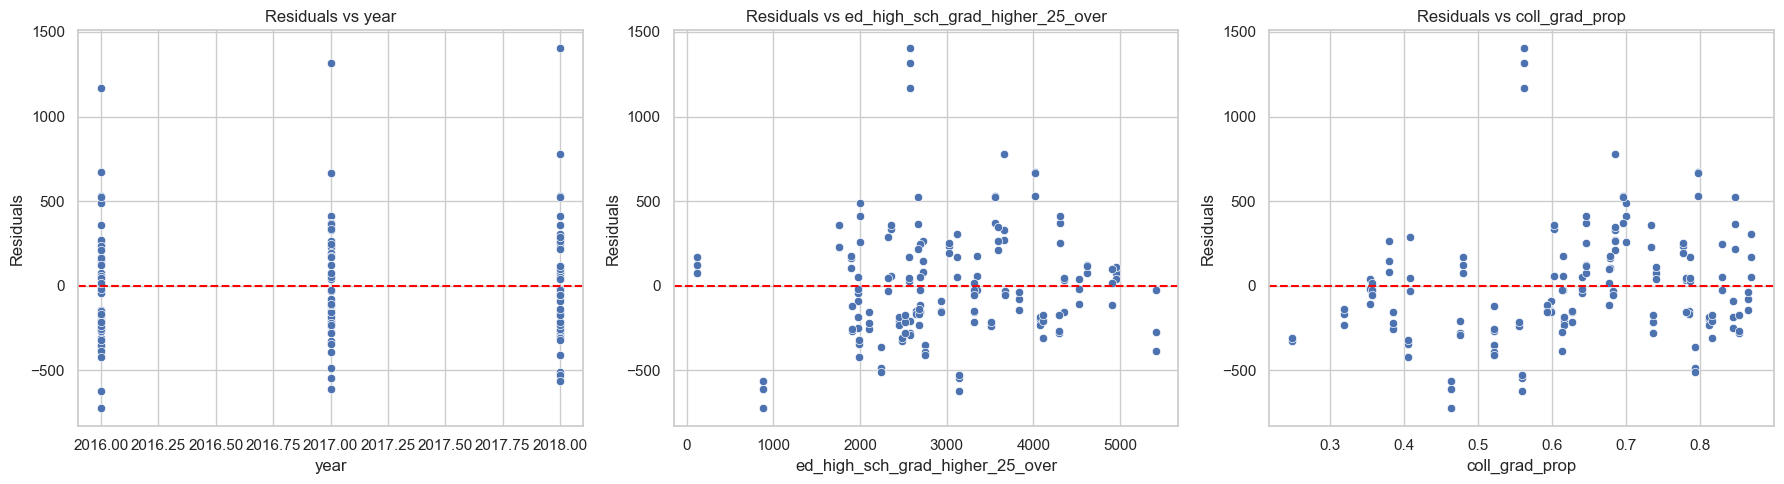

In [13]:
#Calculate residuals
data_reg['residuals'] = model.resid

#Define predictors to examine
predictors_to_plot = ['year', 'ed_high_sch_grad_higher_25_over', 'coll_grad_prop']

#Plot residuals vs each predictor
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, pred in enumerate(predictors_to_plot):
    sns.scatterplot(data=data_reg, x=pred, y='residuals', ax=axes[i])
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"Residuals vs {pred}")
    axes[i].set_ylabel('Residuals')
    axes[i].set_xlabel(pred)

plt.tight_layout()
plt.show()

The residual plots show that errors are generally centered around zero with no systematic bias over time, indicating no temporal trends in model fit. However, for the education-related variables (ed_high_sch_grad_higher_25_over and coll_grad_prop), the residuals display increasing variance and slight curvature, suggesting heteroscedasticity and possible nonlinear effects. This implies that while the model captures broad trends, it may not fully represent complex relationships between education levels and crime rates. Adding interaction or polynomial terms could improve model accuracy.

#### (f) Thinking critically

Amidst data features like population are features like educational attainment per tract. This brings to light the fact that there may be specific demographic and socioeconomic variables/characteristics that are also associated with educational attainment. Whether intentional or not, someone looking at this data might infer a link between crime and educational attainment just due to the variables present. Even worse, someone might use the data to support harsh policing policies based on specific demographics or socioeconomic variables. Discuss, in a few paragraphs, how such datasets could be used (1) in a harmful way, and (2) in a beneficial way for society.

Datasets that combine crime statistics with demographic and educational information have a lot of analytical potential, but they also carry serious ethical risks if they are misunderstood or misused. On the harmful side, this kind of data can easily be used to reinforce stereotypes or justify unfair policing practices. For example, if someone points to a correlation between lower education levels and higher crime rates without considering broader social and historical factors, it can create or strengthen negative assumptions about certain communities. When used carelessly, this kind of analysis can influence policies that lead to increased surveillance or policing in low-income or minority neighborhoods instead of addressing deeper issues like underfunded schools, housing insecurity, or lack of job opportunities. This “data-driven bias” can make discrimination appear objective and further marginalize vulnerable groups.

At the same time, these datasets can be powerful tools for positive change when they are used thoughtfully and ethically. Policymakers and researchers can use them to identify communities that would benefit most from social investment, such as better schools, job training programs, or youth support services. By studying how education and socioeconomic conditions connect to public safety, leaders can design prevention-focused policies that improve opportunity and community well-being instead of relying solely on punishment. Researchers can also use this kind of analysis to expose inequality and advocate for fairer resource distribution.

Ultimately, the impact of these datasets depends on how they are used and interpreted. Ethical use means recognizing that correlation does not prove causation, and that data reflects complex social realities shaped by history, policy, and inequality. It also requires transparency, accountability, and empathy. Analysts, policymakers, and community leaders share a responsibility to approach these findings with humility and to ensure that data is used to promote fairness and trust, not bias or division.